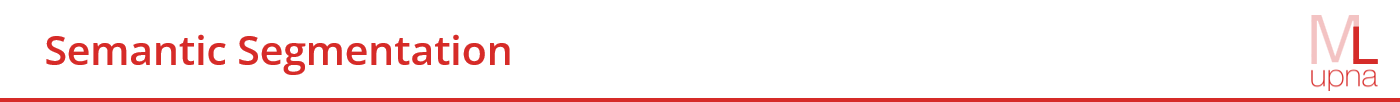

In this exercise, you will learn the fundamentals of <span style="color:#D52B29">semantic segmentation</span>, a core task in computer vision where the goal is to assign a <span style="color:#D52B29">class label</span> to each pixel of an image. Unlike classification, which predicts a single label for an entire image, or detection, which localizes objects with bounding boxes, semantic segmentation provides a much more detailed and structured understanding of visual content.

We will use the <span style="color:#D52B29">Clothing Co-Parsing (CCP)</span> dataset, which contains images of people annotated with pixel-level labels for different clothing categories. To simplify the problem and illustrate the task of segmentation, we will reduce the dataset into a <span style="color:#D52B29">binary problem</span> with only two classes: <span style="color:#D52B29">person</span> / <span style="color:#D52B29">background</span>.

![CCP Dataset](https://raw.githubusercontent.com/bearpaw/clothing-co-parsing/master/example.jpg)

Throughout the notebook, you will explore different approaches to segmentation:

- <span style="color:#D52B29">Sliding window</span> classification of the central pixel.

- <span style="color:#D52B29">Fully convolutional networks (FCNs)</span>.

- The <span style="color:#D52B29">U-Net</span> encoder-decoder architecture.

By the end of this practice, you will understand both the limitations of early approaches and the advantages of modern architectures in semantic segmentation.

## <span style="color:#D52B29">Sliding Window</span>

One of the earliest strategies for <span style="color:#D52B29">semantic segmentation</span> is the <span style="color:#D52B29">sliding window approach</span>. In this method, a fixed-size window is moved across the image, and a classifier predicts the <span style="color:#D52B29">label of the central pixel</span> based on the content inside the window.

While simple to implement, this approach, as we will see in this section, has several drawbacks:

- It is <span style="color:#D52B29">computationally expensive</span> since the network runs on many overlapping patches.

- The model often struggles to capture <span style="color:#D52B29">global context</span> because predictions are based only on local neighborhoods.

Despite these limitations, the sliding window method provides an intuitive first step toward understanding pixel-level classification.

In [20]:
from collections import Counter

In [6]:
# Download from Huggingface
!wget -q --show-progress https://huggingface.co/datasets/cayala/CCP/resolve/main/clothes.zip

# Extract to folder
!unzip -q clothes.zip

# Remove the zip file
!rm clothes.zip

clothes.zip         100%[===================>]  66.20M   105MB/s    in 0.6s    


In [21]:
# Buid dataset from folder structure

from glob import glob
import pandas as pd

images = glob('./clothes/*/images/*')
df = pd.DataFrame(images, columns=['image_path'])
df['mask_path'] = df.image_path.apply(lambda x : x.replace('/images/', '/labels/').replace('.jpg', '.png'))
df['set'] = df.image_path.apply(lambda x : x.split('/')[2])
df.head()

,image_path,mask_path,set
0,./clothes/test/images/0851.jpg,./clothes/test/labels/0851.png,test
1,./clothes/test/images/0852.jpg,./clothes/test/labels/0852.png,test
2,./clothes/test/images/0853.jpg,./clothes/test/labels/0853.png,test
3,./clothes/test/images/0854.jpg,./clothes/test/labels/0854.png,test
4,./clothes/test/images/0855.jpg,./clothes/test/labels/0855.png,test


In [22]:
class_dict_df = pd.read_csv('clothes/class_dict.csv')

In [23]:
class_dict_df['array'] = class_dict_df[['r', 'g', 'b']].apply(lambda row: row.to_numpy(dtype=int), axis=1)

In [24]:
keys = class_dict_df['array'].apply(lambda x: tuple(x))
lookup = dict(zip(keys, class_dict_df['class_name']))
lookup[(np.int64(69), np.int64(6), np.int64(90))] = 'background'

total_objects = []

for path in df['mask_path'].values:
    y = imread(path)
    objects = np.unique(y.reshape(-1, y.shape[2]), axis=0)
    total_objects.extend(lookup.get(tuple(a), None) for a in objects)
    
counts = Counter(total_objects)

# Ordenar por el valor (count), de mayor a menor
sorted_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))

df_counts = pd.DataFrame(
    list(sorted_counts.items()),
    columns=['element', 'count']
)

df_counts.to_csv("clothes/class_counts.csv", index=False)

KeyboardInterrupt: 

In [ ]:
df_counts = pd.read_csv('clothes/class_counts.csv')

plt.figure(figsize=(12, 6))

plt.bar(df_counts['element'], df_counts['count'])

plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Object Counts per Class')

plt.xticks(rotation=90)  # Para que se vean las etiquetas
plt.tight_layout()
plt.show()

In [ ]:
clustering_dict = {
    "no_clothing": [
        "background", "skin", "hair"
    ],
    "upper_wear": [
        "shirt", "t-shirt", "blouse", "top",
        "sweater", "hoodie", "sweatshirt",
        "jacket", "coat", "blazer", "cardigan",
        "vest", "cape", "jumper", "bra"
    ],
    "lower_wear": [
        "pants", "jeans", "skirt", "shorts",
        "leggings", "tights", "stockings",
        "panties"
    ],
    "one_piece_wear": [
        "dress", "romper", "bodysuit", "suit",
        "swimwear"
    ],
    "footwear": [
        "shoes", "sandals", "boots", "sneakers",
        "flats", "heels", "pumps", "wedges",
        "loafers", "socks", "clogs"
    ],
    "accessories": [
        "belt", "scarf", "hat", "gloves",
        "bag", "purse", "wallet", "accessories",
        "bracelet", "necklace", "watch",
        "ring", "earrings", "tie", "sunglasses", "glasses",
        "intimate"
    ]
}

inverse_clustering_dict = {}
for group, items in clustering_dict.items():
    for item in items:
        inverse_clustering_dict[item] = group

df_counts["cluster"] = df_counts["element"].map(inverse_clustering_dict)
df_counts.to_csv("clothes/class_counts.csv", index=False)

In [ ]:
cluster_dict_df = class_dict_df.copy().drop(columns=['r','g','b'])

cluster_dict_df.loc[0, 'class_name'] = 'background'

cluster_dict_df["cluster"] = cluster_dict_df["class_name"].map(inverse_clustering_dict)

cluster_first_array = cluster_dict_df.groupby("cluster")["array"].first().to_dict()
cluster_dict_df["cluster_array"] = cluster_dict_df["cluster"].map(cluster_first_array)

cluster_dict_df.to_csv("clothes/cluster_dict.csv", index=False)

In [ ]:
cluster_dict_df

In [ ]:
cluster_keys = cluster_dict_df['array'].apply(lambda x: tuple(x))
lookup_cluster = dict(zip(cluster_keys, cluster_dict_df['cluster']))

total_clusters = []

for path in df['mask_path'].values:
    y = imread(path)
    clusters = np.unique(y.reshape(-1, y.shape[2]), axis=0)
    total_clusters.extend((np.unique(list(lookup_cluster.get(tuple(a), None) for a in clusters))).tolist())
    
cluster_counts = Counter(total_clusters)

# Ordenar por el valor (count), de mayor a menor
sorted_cluster_counts = dict(sorted(cluster_counts.items(), key=lambda x: x[1], reverse=True))

In [ ]:
df_cluster_counts = pd.DataFrame(
    list(sorted_cluster_counts.items()),
    columns=['cluster', 'count']
)

df_cluster_counts.to_csv("clothes/cluster_counts.csv", index=False)

In [ ]:
df_cluster_counts = pd.read_csv('clothes/cluster_counts.csv')

plt.figure(figsize=(12, 6))

plt.bar(df_cluster_counts['cluster'], df_cluster_counts['count'])

plt.xlabel('Cluster')
plt.ylabel('Frequency')
plt.title('Object Counts per Class')

plt.xticks(rotation=90)  # Para que se vean las etiquetas
plt.tight_layout()
plt.show()

In [ ]:
def read_mask(mask_path):
    y = imread(mask_path)

    clusters = np.unique(y.reshape(-1, y.shape[2]), axis=0)
    
    orig_colors = np.array([np.array(x) for x in cluster_dict_df["array"]])        # (N, 3)
    new_colors  = np.array([np.array(x) for x in cluster_dict_df["cluster_array"]]) # (N, 3)
    
    y_flat = y.reshape(-1, 3)
    
    # Matriz booleana (num_pixels x num_classes)
    matches = (y_flat[:, None, :] == orig_colors[None, :, :]).all(axis=2)
    
    # Índice del color encontrado (o -1 si ninguno)
    idx = matches.argmax(axis=1)
    mask_hit = matches.any(axis=1)
    
    y_out = y_flat.copy()
    y_out[mask_hit] = new_colors[idx[mask_hit]]
    y_out = y_out.reshape(y.shape)

    return y, y_out

In [ ]:
# Inspect a randomly taken sample
import matplotlib.pyplot as plt
from skimage.io import imread
import os
import numpy as np

r = df.sample(1).iloc[0]

x = imread(r.image_path)
y, y_out = read_mask(r.mask_path)

f, ax = plt.subplots(1, 4, figsize=(25, 5))

f.suptitle(f'Sample: {r.set} - {os.path.basename(r.image_path).split(".")[0]} ')

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Mask')

ax[2].imshow(y_out)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Mask 2')

ax[3].imshow(x)
ax[3].imshow(y_out, alpha=.5)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Overlay')

# ax[3].imshow(x)


plt.show()

In [ ]:
np.unique(y_out.reshape(-1, y.shape[2]), axis=0)

We start by creating a function that extracts a <span style="color:#D52B29">random patch</span> from an image and assigns it the class corresponding to the <span style="color:#D52B29">central pixel</span> of the patch. It is important to note that, for model training, we will select <span style="color:#D52B29">random patches</span> from the images, since extracting all possible patches corresponding to every pixel in the training images would be <span style="color:#D52B29">computationally infeasible</span>.

## <span style="color:#D52B29">Encoder-Decoder Architecture</span>

In previous sections, we saw that convolutional networks used for classification extract information from the original image at multiple levels. Each level compresses information more, producing richer features. However, in the first strategy (sliding window), this does not help for segmentation since we would need to classify pixel by pixel.

The second strategy we explored does not compress the information and works at the original resolution, allowing segmentation in a single pass. Unfortunately, it is also not ideal due to the high computational cost.

The solution is to <span style="color:#D52B29">combine both approaches</span>. We will use <span style="color:#D52B29">FCNNs that internally compress and decompress information</span>. Pooling layers reduce dimensionality (<span style="color:#D52B29">encoder</span>), while deconvolution or upsampling layers restore it (<span style="color:#D52B29">decoder</span>). Additionally, most architectures include <span style="color:#D52B29">skip-connections</span> that transfer information from the encoder to the decoder for more precise reconstruction.

Among encoder-decoder architectures, there are many variations. Fastai focuses on the most widely used one due to its strong generalization across tasks: the <span style="color:#D52B29">U-Net</span>, named after the "U" shape of its structure, as illustrated below.

![Arquitectura Unet](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)

Imagen from: [U-Net: Convolutional Networks for Biomedical Image Segmentation
](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/#:~:text=The%20u%2Dnet%20is%20convolutional,and%20precise%20segmentation%20of%20images.&text=U%2Dnet%20architecture%20(example%20for,on%20top%20of%20the%20box.).

As we can see, the architecture starts with a CNN-like <span style="color:#D52B29">encoder</span>, consisting of convolutional and pooling layers. This part can be replaced with any CNN we’ve seen before (e.g., <span style="color:#D52B29">ResNet</span>), also called the <span style="color:#D52B29">backbone</span>. After compression, the <span style="color:#D52B29">decoder</span> uses upsampling and convolutional layers to restore spatial resolution. The horizontal arrows are <span style="color:#D52B29">skip-connections</span>, which pass features from each encoder level to the corresponding decoder layer, improving spatial accuracy.

Although there are technical complexities like undoing pooling (<span style="color:#D52B29">upsampling</span>) or implementing deconvolutions, these details are abstracted when using Fastai’s <span style="color:#D52B29">U-Net</span> implementation, so we will focus on its practical use rather than the low-level operations.

To implement the <span style="color:#D52B29">U-Net</span> and other more advanced semantic segmentation architectures, we will use the <span style="color:#D52B29">Segmentation Models PyTorch</span> library. This library allows us to easily choose different encoders and configure various internal parameters of the network.

Next, we will see how to instantiate a <span style="color:#D52B29">U-Net</span> that uses a <span style="color:#D52B29">ResNet18 encoder</span> pre-trained on ImageNet.

In [41]:
import segmentation_models_pytorch as smp
import pytorch_lightning as pl
from torch.nn import functional as F
from collections import defaultdict
from torchvision.models import ResNet18_Weights
from lightning.pytorch.loggers import CSVLogger
from torchvision.transforms.functional import to_pil_image
import torchvision.transforms.v2 as T
import torchvision
import torch
import matplotlib.pyplot as plt
from skimage.io import imread
import os
import numpy as np
from collections import Counter
from glob import glob
import pandas as pd
from PIL import Image
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torch.optim.lr_scheduler import ReduceLROnPlateau
from fastprogress import master_bar, progress_bar

In [27]:
images = glob('./clothes/*/images/*')
df = pd.DataFrame(images, columns=['image_path'])
df['mask_path'] = df.image_path.apply(lambda x : x.replace('/images/', '/labels/').replace('.jpg', '.png'))
df['set'] = df.image_path.apply(lambda x : x.split('/')[2])
df.head()

,image_path,mask_path,set
0,./clothes/test/images/0851.jpg,./clothes/test/labels/0851.png,test
1,./clothes/test/images/0852.jpg,./clothes/test/labels/0852.png,test
2,./clothes/test/images/0853.jpg,./clothes/test/labels/0853.png,test
3,./clothes/test/images/0854.jpg,./clothes/test/labels/0854.png,test
4,./clothes/test/images/0855.jpg,./clothes/test/labels/0855.png,test


In [28]:
# class CustomMask():
#     def __init__(self):
#         self.cluster_dict_df = pd.read_csv("clothes/cluster_dict.csv")
#         self.orig_colors = np.array([np.fromstring(x.strip('[]'), sep=' ').astype(int) for x in self.cluster_dict_df["array"]])        # (N, 3)
#         self.new_colors  = np.array([np.fromstring(x.strip('[]'), sep=' ').astype(int) for x in self.cluster_dict_df["cluster_array"]]) # (N, 3)

#         self.cluster_counts = pd.read_csv("clothes/cluster_counts.csv")

#         self.unique_clusters_df = self.cluster_dict_df[['cluster', 'cluster_array']].drop_duplicates()
#         self.array_to_label = dict(zip(self.unique_clusters_df["cluster_array"], range(6)))

#     def read_mask(self, mask_path):
#         y = imread(mask_path)
    
#         clusters = np.unique(y.reshape(-1, y.shape[2]), axis=0)
        
#         y_flat = y.reshape(-1, 3)
        
#         # Matriz booleana (num_pixels x num_classes)
#         matches = (y_flat[:, None, :] == self.orig_colors[None, :, :]).all(axis=2)
        
#         # Índice del color encontrado (o -1 si ninguno)
#         idx = matches.argmax(axis=1)
#         mask_hit = matches.any(axis=1)
        
#         y_out = y_flat.copy()
#         y_out[mask_hit] = self.new_colors[idx[mask_hit]]
#         y_out = y_out.reshape(y.shape)
    
#         return y, y_out

#     def mask_to_labels(self, y):
#         h, w, _ = y.shape
#         y_flat = y.reshape(-1, 3)
    
#         # Convert each pixel to its string representation "[r g b]"
#         pixel_strings = np.apply_along_axis(
#             lambda row: str(row),
#             1,
#             y_flat
#         )
        
#         # Map each pixel string to its label (default -1)
#         labels = np.array([self.array_to_label.get(s, -1) for s in pixel_strings])
#         labeled_mask = labels.reshape(h, w)
        
#         return labeled_mask


In [29]:
class CustomMask:
    def __init__(self):
        df = pd.read_csv("clothes/cluster_dict.csv")
        self.cluster_counts = pd.read_csv("clothes/cluster_counts.csv")

        # Convert string "[r g b]" -> tuple (r, g, b)
        def to_tuple(s):
            return tuple(map(int, s.strip("[]").split()))

        df["orig_tuple"]   = df["array"].apply(to_tuple)
        df["new_tuple"]    = df["cluster_array"].apply(to_tuple)

        # Arrays (mantengo por si necesitas vectorización)
        self.orig_colors = np.array(df["orig_tuple"].tolist())
        self.new_colors  = np.array(df["new_tuple"].tolist())

        # Diccionarios clave para máxima velocidad
        self.map_orig_to_new = dict(zip(df["orig_tuple"], df["new_tuple"]))

        # Diccionario para labels (cluster_array → int)
        unique = df[["cluster", "cluster_array"]].drop_duplicates()
        unique["tuple"] = unique["cluster_array"].apply(to_tuple)
        self.map_tuple_to_label = {
            tpl: i for i, tpl in enumerate(unique["tuple"])
        }

    def read_mask(self, mask_path):
        y = imread(mask_path)
        h, w, _ = y.shape
        
        # Crear un array de índices únicos para cada color
        y_reshaped = y.reshape(-1, 3)
        
        # Vectorizar la búsqueda usando broadcasting
        # Comparar todos los píxeles con todos los colores originales de una vez
        matches = (y_reshaped[:, None] == self.orig_colors).all(axis=2)
        indices = np.argmax(matches, axis=1)
        
        # Aplicar la transformación
        out = np.where(matches.any(axis=1)[:, None], 
                       self.new_colors[indices], 
                       y_reshaped)
        
        return y, out.reshape(h, w, 3).astype(np.uint8)

    def mask_to_labels(self, y):
        h, w, _ = y.shape
        y_flat = y.reshape(-1, 3)
        
        # Crear array de labels correspondiente a new_colors
        label_array = np.array([self.map_tuple_to_label.get(tuple(c), -1) 
                                for c in self.new_colors])
        
        # Vectorizar la búsqueda
        matches = (y_flat[:, None] == self.new_colors).all(axis=2)
        indices = np.argmax(matches, axis=1)
        labels = np.where(matches.any(axis=1), label_array[indices], -1)
        
        return labels.reshape(h, w)

In [30]:
class CCPDataset(torch.utils.data.Dataset):

    def __init__(self, df, patch_size=224, transforms=None, mode='train'):
        super(CCPDataset, self).__init__()
        self.df = df
        self.ps = patch_size
        self.transforms = transforms
        self.mode = mode
        self.custom_mask = CustomMask()
        
    def __getitem__(self, idx):

        # Take the idx-th row from the DataFrame
        r = self.df.iloc[idx]

        # Read image and mask
        x = imread(r.image_path)
        _, y = self.custom_mask.read_mask(r.mask_path)
        y = self.custom_mask.mask_to_labels(y)
        
        # Convert into binary mask
        # y = (y != np.array([69,  6, 90])).any(-1)

        if self.mode == 'eval': # If we are evaluating (valid or test set) perform a subset based on the given coordinates
            x = x[r.coords[0]:r.coords[0]+self.ps, r.coords[1]:r.coords[1]+self.ps]
            y = y[r.coords[0]:r.coords[0]+self.ps, r.coords[1]:r.coords[1]+self.ps]
                    
        # Convert to PIL image. Converting to PIL before calling the v2 transforms makes the behavior consistent across torchvision versions.
        x = to_pil_image(x.astype('float32'))
        y = to_pil_image(y.astype('uint8'), mode='L')
        
        # Apply transforms
        if self.transforms:
            x, y = self.transforms[0](x, y) # First, transforms for both image and mask synchronized
            x = self.transforms[1](x) # Second, tranforms for only images

        # PIL to Tensor
        y = (torchvision.transforms.functional.to_tensor(y) > 0).type(torch.long)
            
        return x, y

    def __show_item__(self, x, y):
        f, ax = plt.subplots(1, 3, figsize=(15, 5))

        ax[0].imshow(x.permute(1, 2, 0))
        ax[0].set_title('Image')
        ax[0].set_xticks([])
        ax[0].set_yticks([])

        ax[1].imshow(y[0])
        ax[1].set_title('Mask')
        ax[1].set_xticks([])
        ax[1].set_yticks([])

        ax[2].imshow(x.permute(1, 2, 0))
        ax[2].imshow(y[0], alpha=.5, vmin=0, vmax=1)
        ax[2].set_title('Overlay')
        ax[2].set_xticks([])
        ax[2].set_yticks([])

        plt.show()
        

    def __len__(self): 
        return self.df.shape[0]

In [31]:
import pytorch_lightning as pl

class DataModule(pl.LightningDataModule):
    def __init__(self, df, bs, ps):
        super().__init__()
        self.df = df
        self.bs = bs
        self.ps = ps
        
    def get_image_shape(self, path):
        with Image.open(path) as img:
            return img.size[::-1]  # (height, width)
                
    def patch_origins(self, h, w, ps, overlap=.5):
    
        if ps > h or ps > w:
            raise ValueError("Patch size ps must be <= image dimensions h and w")
    
        stride = int(ps * overlap)
        if stride <= 0:
            raise ValueError("Patch size too small")
    
        hs = list(range(0, h - ps + 1, stride))
        ws = list(range(0, w - ps + 1, stride))
    
        # make sure the last patch touches the image border
        if hs[-1] != h - ps:
            hs.append(h - ps)
        if ws[-1] != w - ps:
            ws.append(w - ps)
    
        origins = [(h, w) for h in hs for w in ws]
        return np.array(origins, dtype=int)

    def setup(self, stage): # Data preparation and transforms

        train_transforms = (
            T.Compose([
                T.RandomCrop((224, 224)),
                T.Resize(size=(256, 256)),                
            ]),
            T.Compose([
                T.ToImage(), 
                T.ToDtype(torch.float32, scale=True),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
        )

        eval_transforms = (
            T.Compose([
                T.Resize(size=(256, 256)),    
            ]),
            T.Compose([
                T.ToImage(), 
                T.ToDtype(torch.float32, scale=True),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
        )
        
        self.train_ds = CCPDataset(df=self.df.query('set == "train"'), patch_size=self.ps, transforms=train_transforms)

        valid_df = self.df.query('set == "valid"')

        valid_df['coords'] = valid_df.image_path.apply(
            lambda x: self.patch_origins(*self.get_image_shape(x), ps=224, overlap=1).tolist()
        )
        valid_df = valid_df.explode('coords')

        test_df = self.df.query('set == "test"')
        test_df['coords'] = test_df.image_path.apply(
            lambda x: self.patch_origins(*self.get_image_shape(x), ps=224, overlap=1).tolist()
        )
        test_df = test_df.explode('coords')
        
        self.valid_ds = CCPDataset(df=valid_df, patch_size=self.ps, transforms=eval_transforms, mode='eval')
        self.test_ds = CCPDataset(df=test_df, patch_size=self.ps, transforms=eval_transforms, mode='eval')

    def train_dataloader(self): return torch.utils.data.DataLoader(self.train_ds, batch_size=self.bs, shuffle=True, num_workers=4)

    def val_dataloader(self): return torch.utils.data.DataLoader(self.valid_ds, batch_size=self.bs, shuffle=False, num_workers=4)

    def test_dataloader(self): return torch.utils.data.DataLoader(self.test_ds, batch_size=self.bs, shuffle=False, num_workers=4)
	

In [32]:
N_CLASSES = 6

In [33]:
model = smp.DeepLabV3(
    encoder_name='resnet18',
    encoder_weights='imagenet',
    in_channels=3,
    classes=N_CLASSES
)

model

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

DeepLabV3(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

We are now going to modify the <span style="color:#D52B29">LightningModule</span> to make use of this new <span style="color:#D52B29">U-Net model</span> and train it with the same parametrization as in the previous experiments, ensuring a <span style="color:#D52B29">fair comparison</span>.

In [35]:
class LightningModule(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.save_hyperparameters()
        
        # Creating model
        self.model = smp.Unet(
            encoder_name='resnet18',
            encoder_weights='imagenet',
            in_channels=3,
            classes=6
        )

        self.training_step_outputs = defaultdict(float)
        self.validation_step_outputs = defaultdict(float)
        
    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)

        # Configure ReduceLROnPlateau scheduler
        scheduler = ReduceLROnPlateau(
            optimizer,
            mode='min',           # Minimize the monitored metric
            factor=0.1,          # Multiply LR by this factor when reducing
            patience=5,          # Number of epochs with no improvement before reducing LR
            threshold=0.01,      # Threshold for measuring improvement
            threshold_mode='rel', # 'rel' for relative change, 'abs' for absolute
            cooldown=0,          # Number of epochs to wait before resuming normal operation
            min_lr=1e-6,         # Lower bound on the learning rate
            eps=1e-8             # Minimal decay applied to lr
        )
        
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_loss',  # Metric to monitor
                'interval': 'epoch',     # Update scheduler after each epoch
                'frequency': 1,          # Check metric every epoch
                'strict': True,          # Enforce that monitored metric exists
            }
        }

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y.squeeze(1)) # y: (BS, 1, H, W) -> (BS, H, W)
        
        self.log('train_loss', loss, on_step=False, on_epoch=True)
        self.training_step_outputs['loss'] += loss.detach().cpu()
        self.training_step_outputs['steps'] += 1
        
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y.squeeze(1))
        
        self.log('val_loss', loss, on_step=False, on_epoch=True)
        self.validation_step_outputs['loss'] += loss.detach().cpu()
        self.validation_step_outputs['steps'] += 1
        
        return loss

    def on_train_epoch_end(self): 
        avg_loss = self.training_step_outputs['loss'] / self.training_step_outputs['steps']
        print(f"Average training loss for epoch {self.current_epoch}: {avg_loss.item():.4f}")
        self.training_step_outputs.clear() 

    def on_validation_epoch_end(self):
        avg_loss = self.validation_step_outputs['loss'] / self.validation_step_outputs['steps']
        print(f"Average validation loss for epoch {self.current_epoch}: {avg_loss.item():.4f}")
        self.validation_step_outputs.clear() 

In [36]:
# Set random seed for reproducibility
pl.seed_everything(seed=42, workers=True)

# Intantiate LightningModule
lightning_module = LightningModule()

# Define a CSV logger to store training/validation metrics in CSV format.
csv_logger = CSVLogger(save_dir=os.getcwd(), name="ccp_deeplabv3")

# Define a checkpoint callback:
# It will save the model with the lowest validation loss ("best_valid_loss.ckpt").
model_checkpoint_callback = pl.callbacks.model_checkpoint.ModelCheckpoint(
    monitor='val_loss',mode='min', filename='best_valid_loss', verbose=True, save_last=False)
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.01,
    patience=10,
    verbose=False,
    mode="min"
)
# Create a PyTorch Lightning trainer
trainer = pl.Trainer(max_epochs=100, logger=csv_logger, callbacks=[early_stop_callback, model_checkpoint_callback])

# Load the data module
data_module = DataModule(df, bs=32, ps=224)

# Train the model with the trainer, passing the core LightningModule and data module.
trainer.fit(lightning_module, data_module)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX A6000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/tmp/ipykernel_5065/272022990.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['coords'] = valid_df.image_path.apply(
/tmp/ipykernel_5065/272022990.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

Average validation loss for epoch 0: 2.2964


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (22) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                               | 0/? [00:00<?, ?it/s]

...

Average validation loss for epoch 28: 0.0816
Average training loss for epoch 28: 0.0848


Validation: |                                             | 0/? [00:00<?, ?it/s]

Epoch 29, global step 660: 'val_loss' reached 0.07113 (best 0.07113), saving model to '/home/alumno/Desktop/datos/Computer Vision/Assignment 06/clothing-co-parsing/ccp_deeplabv3/version_0/checkpoints/best_valid_loss.ckpt' as top 1


Average validation loss for epoch 29: 0.0708
Average training loss for epoch 29: 0.0839


`Trainer.fit` stopped: `max_epochs=30` reached.


   epoch  step  train_loss   val_loss
0      0    21    1.416134  21.484030
1      1    43    0.606586   0.351906
2      2    65    0.305604   0.204566
3      3    87    0.236969   0.162051
4      4   109    0.209051   0.175642


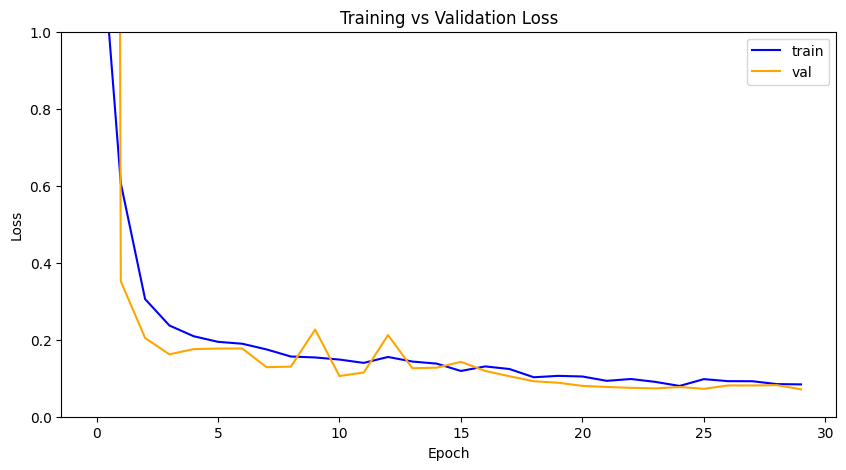

In [38]:
metric_df = pd.read_csv(f'{trainer.logger.log_dir}/metrics.csv')
metric_df = metric_df.groupby('epoch', as_index=False).first()
print(metric_df.head())

f, ax = plt.subplots(1, 1, figsize=(10, 5))
metric_df.train_loss.plot(ax=ax, color='blue', label='train')
metric_df.val_loss.plot(ax=ax, color='orange', label='val')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss')
ax.set_ylim((0, 1))
ax.legend()
plt.show()

We will now load the best model and perform inference as before, in order to compute metrics and compare this approach with the previous ones.

In [39]:
# Load the best model
model = LightningModule.load_from_checkpoint(model_checkpoint_callback.best_model_path, model=model)
model.cuda(0) # Move to GPU
model.eval()

LightningModule(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1):

In [51]:
import torch.nn as nn
from sklearn.metrics import accuracy_score, jaccard_score, f1_score

In [52]:
ps = 256 # Imagenet Resizes to 256

inf_transforms = T.Compose([
    # T.Resize(size=(256, 256)),    
    T.ToImage(), 
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

metric_dict = []

test_df = df.query('set == "test"')

mb = master_bar(test_df.iterrows(), total=test_df.shape[0])
cm = CustomMask()

for i, r in mb:

    # Read image and mask
    x = imread(r.image_path)
    y = imread(r.mask_path)
    
    # Convert into label mask
    _, y = cm.read_mask(r.mask_path)
    y = cm.mask_to_labels(y)

    # Compute origins
    h, w = y.shape
    coords = DataModule.patch_origins(None, h, w, ps=ps, overlap=1).tolist()

    # Initialize y_hat
    y_hat = torch.zeros((N_CLASSES, h, w), dtype=torch.float32)
    y_wei = torch.zeros((N_CLASSES, h, w), dtype=torch.uint8) # Times each pixel has been infered
    
    # Perform inference
    for (coord_x, coord_y) in progress_bar(coords, parent=mb):
            
        # Crop
        xi = x[coord_x:coord_x+ps, coord_y:coord_y+ps]
        
        # Convert to PIL image.
        xi = to_pil_image(xi.astype('float32'))
        
        # Apply transforms
        xi = inf_transforms(xi)

        # Forward
        with torch.no_grad():
            logits = model(xi.cuda(0).unsqueeze(0))
            logits = nn.Softmax(1)(logits).detach().cpu()[0]

        # Store predictions
        y_hat[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += logits
        y_wei[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += 1

    # Normalize logits and gen binary mask
    y_hat /= y_wei
    y_hat_bin = y_hat.argmax(0)

    # Compute metrics
    metric_dict.append({
        'pixel_acc': accuracy_score(y_hat_bin.ravel(), y.ravel()),
        'iou': jaccard_score(y_hat_bin.ravel(), y.ravel()),
        'dice': f1_score(y_hat_bin.ravel(), y.ravel())
    })

In [53]:
pd.DataFrame.from_records(metric_dict).mean(0)

pixel_acc    0.934725
iou          0.749415
dice         0.849783
dtype: float64

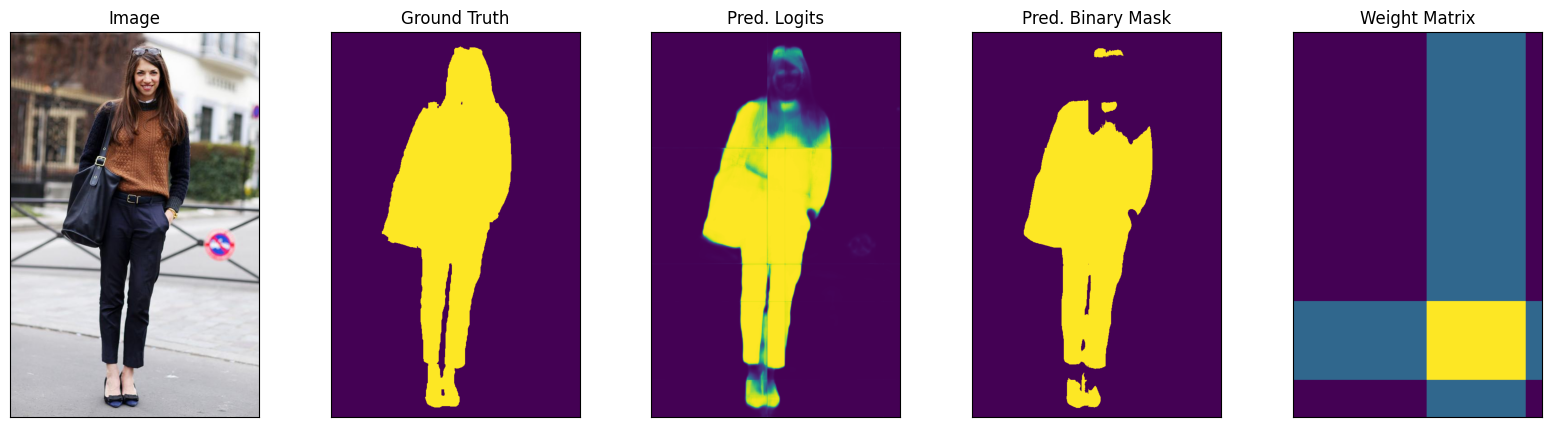

In [54]:
f, ax = plt.subplots(1, 5, figsize=(20, 5))

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Ground Truth')

ax[2].imshow(y_hat[1])
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Pred. Logits')

ax[3].imshow(y_hat_bin)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Pred. Binary Mask')

ax[4].imshow(y_wei[0])
ax[4].set_xticks([])
ax[4].set_yticks([])
ax[4].set_title('Weight Matrix')

plt.show()

As we can see, the results obtained with <span style="color:#D52B29">U-Net</span> are the best so far. We not only gain in <span style="color:#D52B29">efficiency</span> but also in <span style="color:#D52B29">accuracy</span>. This strategy is therefore the one we should follow to tackle <span style="color:#D52B29">semantic segmentation</span> problems.

| Experiment      | Inference time    | Sample | Accuracy | IoU  | Dice |
|:---------------:|:----------------:|:------:|:--------:|:----:|:----:|
| Sliding Window  | 30m* / image     | 0851   | 83.89    | 0.56 | 0.71 |
| FCNN            | 1s / image       | 0851   | 79.76    | 0.34 | 0.51 |
| U-Net           | 1s / image       | 0851   | 94.98    | 0.81 | 0.89 |

*Inference time for the sliding window approach may be reduced applying batches.

There are, of course, other <span style="color:#D52B29">semantic segmentation</span> architectures besides U-Net (although most share the same <span style="color:#D52B29">encoder-decoder</span> principle). The <span style="color:#D52B29">segmentation models pytorch</span> library makes it easy to try out different configurations. I encourage you to experiment with them!

## <span style="color:#D52B29">Summary</span>

In this exercise, you have learned the fundamentals of <span style="color:#D52B29">semantic segmentation</span>, a key task in <span style="color:#D52B29">computer vision</span> where the goal is to assign a <span style="color:#D52B29">class label</span> to each pixel of an image. Unlike <span style="color:#D52B29">classification</span>, which predicts a single label for an entire image, or <span style="color:#D52B29">detection</span>, which localizes objects with bounding boxes, segmentation provides a much more detailed and structured understanding of visual content.

We have worked with the <span style="color:#D52B29">Clothing Co-Parsing (CCP)</span> dataset, simplified into a <span style="color:#D52B29">binary problem</span> with only two classes: <span style="color:#D52B29">person</span> / <span style="color:#D52B29">background</span>.

Throughout the notebook, you explored three different approaches to segmentation:

- <span style="color:#D52B29">Sliding window</span> classification of the central pixel.

- <span style="color:#D52B29">Fully convolutional networks (FCNs)</span>.

- The <span style="color:#D52B29">U-Net</span> encoder-decoder architecture.

You have seen how early methods, like the sliding window, can be conceptually simple but computationally inefficient. The FCN approach introduced a step forward, producing full-resolution masks in a single pass, but still suffered from accuracy issues. Finally, the U-Net architecture combined the strengths of both approaches by compressing and then reconstructing the information with the help of <span style="color:#D52B29">skip-connections</span>, leading to the best results both in terms of <span style="color:#D52B29">efficiency</span> and <span style="color:#D52B29">accuracy</span>.

As a takeaway, you should now understand not only how different architectures perform in practice, but also why <span style="color:#D52B29">encoder-decoder models</span> such as <span style="color:#D52B29">U-Net</span> have become the standard in semantic segmentation. Finally, remember that there are many other segmentation architectures beyond U-Net (most sharing the encoder-decoder principle), and the <span style="color:#D52B29">segmentation models pytorch</span> library makes it easy to experiment with them.